<a href="https://colab.research.google.com/github/ksantos-helo/Challenge---TelecomX_BR/blob/main/Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introdução ao Projeto

Este projeto tem como objetivo analisar os fatores que influenciam a evasão de clientes (Churn) em uma empresa de telecomunicações.

A análise busca identificar padrões e variáveis que contribuem para o cancelamento do serviço.


# 1. Importação das bibliotecas


In [29]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Ingestão de Dados – Coleta via API

Nesta etapa realizamos a conexão com a API da Telecom X, extraímos os dados no formato JSON e os convertemos para um DataFrame do Pandas para permitir a manipulação e análise dos dados.

In [30]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:

    response = requests.get(url, timeout=10)

    response.raise_for_status()

    data = response.json()

    df = pd.json_normalize(data)

    print("Dados carregados com sucesso!")
    print("Linhas e colunas:", df.shape)

except requests.exceptions.RequestException as e:

    print("Erro ao acessar API:", e)


Dados carregados com sucesso!
Linhas e colunas: (7267, 21)


#3. Exploração inicial do dataset
   - 3.1 Visualização das colunas

   - 3.2 Verificação dos tipos de dados

   - 3.3 Análise das variáveis categóricas

   - 3.4 Dicionário de dados

## 3.1 Visualização das Colunas

Objetivo: entender estrutura geral do dataset.

In [5]:
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [6]:
df.shape


(7267, 21)

In [7]:
df.columns



Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [8]:
for coluna in df.columns:
    print(coluna)


customerID
Churn
customer.gender
customer.SeniorCitizen
customer.Partner
customer.Dependents
customer.tenure
phone.PhoneService
phone.MultipleLines
internet.InternetService
internet.OnlineSecurity
internet.OnlineBackup
internet.DeviceProtection
internet.TechSupport
internet.StreamingTV
internet.StreamingMovies
account.Contract
account.PaperlessBilling
account.PaymentMethod
account.Charges.Monthly
account.Charges.Total


## 3.2 Verificação dos Tipos de Dados

Objetivo:

- identificar tipos de variáveis

- encontrar valores ausentes

- entender estrutura das features

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [12]:
df.dtypes


,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


## 3.3 Análise das Variáveis Categóricas

Objetivo:

- verificar categorias existentes

- identificar possíveis inconsistências

## 3.4 Dicionário de Dados

Objetivo:

- entender o significado das variáveis

- facilitar interpretação da análise.

customerID: número de identificação único de cada cliente

Churn: se o cliente deixou ou não a empresa

gender: gênero (masculino e feminino)

SeniorCitizen: informação sobre um cliente ter ou não idade igual ou maior que 65 anos

Partner: se o cliente possui ou não um parceiro ou parceira

Dependents: se o cliente possui ou não dependentes

tenure: meses de contrato do cliente

PhoneService: assinatura de serviço telefônico

MultipleLines: assisnatura de mais de uma linha de telefone

InternetService: assinatura de um provedor internet

OnlineSecurity: assinatura adicional de segurança online

OnlineBackup: assinatura adicional de backup online

DeviceProtection: assinatura adicional de proteção no dispositivo

TechSupport: assinatura adicional de suporte técnico, menos tempo de espera

StreamingTV: assinatura de TV a cabo

StreamingMovies: assinatura de streaming de filmes

Contract: tipo de contrato

PaperlessBilling: se o cliente prefere receber online a fatura

PaymentMethod: forma de pagamento

Charges.Monthly: total de todos os serviços do cliente por mês

Charges.Total: total gasto pelo cliente


## 3.5 Separação das variáveis por categoria

Separar variáveis por categoria (baseado no dicionário)

In [13]:
demograficas = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]


In [14]:
servicos = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]


In [15]:
conta = [
    'tenure',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]


In [16]:
financeiro = [
    'Charges.Monthly',
    'Charges.Total'
]


In [31]:
target = 'Churn'


## 3.6 Estatísticas gerais do dataset

In [41]:
df.describe(include='all')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
count,7267,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7256.000000
unique,7267,3,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,NaN
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,...,3182,3195,3582,2896,2870,4005,4311,2445,NaN,NaN
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,2280.634213
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,2268.632997
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,400.225000
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,1391.000000
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,3785.300000


# 4. Tratamento e Preparação dos Dados (ETL)

## 4.1 Verificação de valores *ausentes*

In [10]:
df.isnull().sum()


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


## 4.2 Verificação de duplicados

In [32]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.drop_duplicates()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


## 4.3 Verificação de inconsistências nas categorias

In [9]:
for coluna in df.select_dtypes(include='object').columns:
    print(f"\n{coluna}")
    print(df[coluna].value_counts())



customerID
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

Churn
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

customer.gender
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

customer.Partner
customer.Partner
No     3749
Yes    3518
Name: count, dtype: int64

customer.Dependents
customer.Dependents
No     5086
Yes    2181
Name: count, dtype: int64

phone.PhoneService
phone.PhoneService
Yes    6560
No      707
Name: count, dtype: int64

phone.MultipleLines
phone.MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

internet.InternetService
internet.InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

internet.OnlineSecurity
internet.OnlineSecurity
No  

## 4.4 Verificação de tipos de dados

In [21]:
df['account.Charges.Total'].dtype

dtype('O')

## 4.5 Conversão para tipo numérico

In [37]:
# converter total charges
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

## 4.6 Verificação de valores nulos

In [34]:
df['account.Charges.Total'].isnull().sum()

np.int64(0)

In [52]:
df['Churn'].isnull().sum()

np.int64(224)

## 4.7 Tratamento de valores nulos

In [36]:
# tratar nulos
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

In [54]:
# remover registros sem informação de churn
df = df[df['Churn'].notna() & (df['Churn'] != '')]

## 4.8 Padronização e Transformação de Dados


In [48]:
# padronizar valores de texto
df['customer.Partner'] = df['customer.Partner'].replace({
    'Yes': 1,
    'No': 0
})

df['customer.Dependents'] = df['customer.Dependents'].replace({
    'Yes': 1,
    'No': 0
})

# renomear colunas para facilitar análise
df = df.rename(columns={
    'account.Charges.Total': 'TotalCharges',
    'account.Charges.Monthly': 'MonthlyCharges'
})

/tmp/ipykernel_1066/2005086741.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['customer.Partner'] = df['customer.Partner'].replace({
/tmp/ipykernel_1066/2005086741.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['customer.Dependents'] = df['customer.Dependents'].replace({


In [49]:
# transformar churn em variável binária
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# 5. Análise Exploratória (EDA)

## 5.1 Distribuição da variável alvo

Distribuição do Churn
 - Objetivo: entender quantos clientes cancelaram e quantos permaneceram.

In [81]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


In [55]:
df['Churn'].value_counts()


,count
Churn,
0.0,5174
1.0,1869


In [56]:
df['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
0.0,73.463013
1.0,26.536987


In [83]:
churn_contract = (
    df.groupby('account.Contract')['Churn']
    .mean()
    .sort_values(ascending=False) * 100
)

print(churn_contract)

account.Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


## 5.2 Estatísticas das variáveis numéricas

In [42]:
df.describe()


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


In [47]:
df.describe()

# mediana das variáveis numéricas
df.median(numeric_only=True)

,0
customer.SeniorCitizen,0.0
customer.tenure,29.0
account.Charges.Monthly,70.3
account.Charges.Total,1391.0


# 6. Visualização de dados

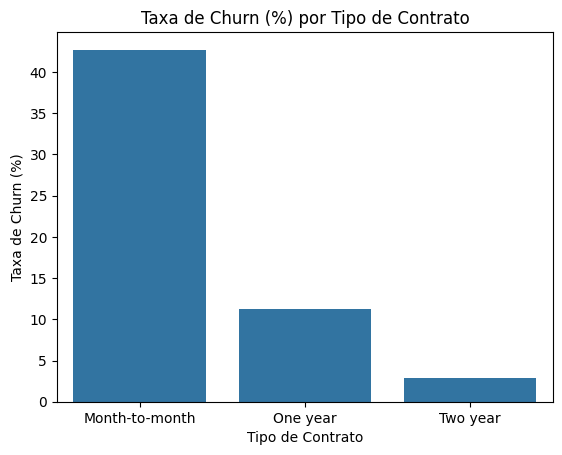

In [85]:
churn_contract = (
    df.groupby('account.Contract')['Churn']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure()

sns.barplot(data=churn_contract, x='account.Contract', y='Churn')

plt.title('Taxa de Churn (%) por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Taxa de Churn (%)')

plt.show()

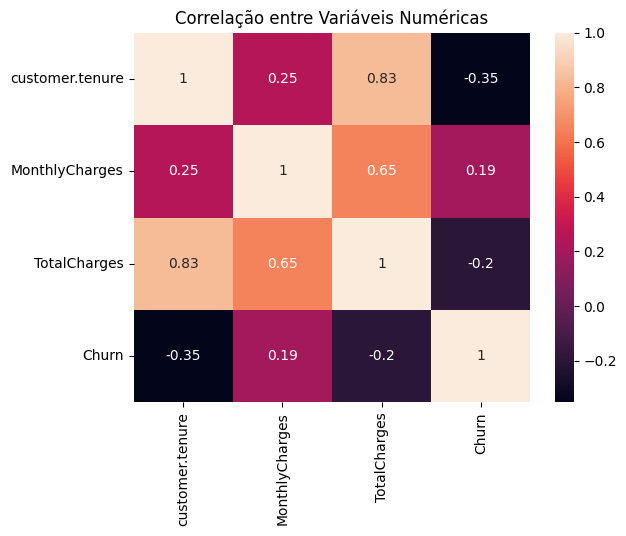

In [84]:
plt.figure()

correlacao = df[['customer.tenure','MonthlyCharges','TotalCharges','Churn']].corr()

sns.heatmap(correlacao, annot=True)

plt.title('Correlação entre Variáveis Numéricas')

plt.show()

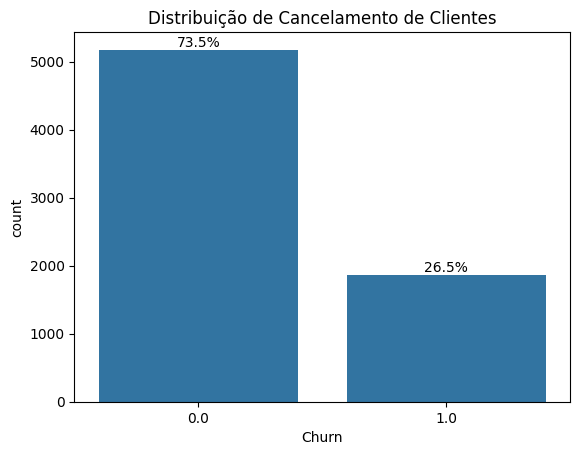

In [58]:
ax = sns.countplot(data=df, x='Churn')

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribuição de Cancelamento de Clientes')
plt.show()

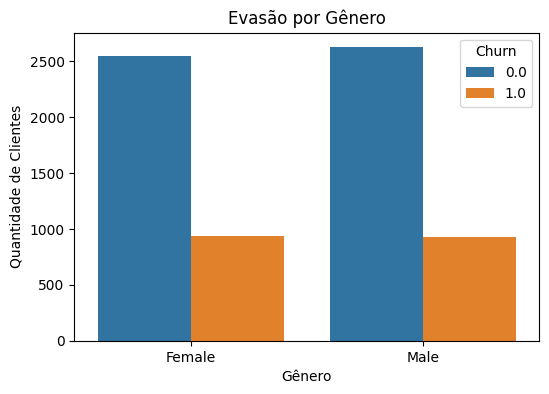

In [67]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='customer.gender', hue='Churn')

plt.title('Evasão por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')

plt.show()

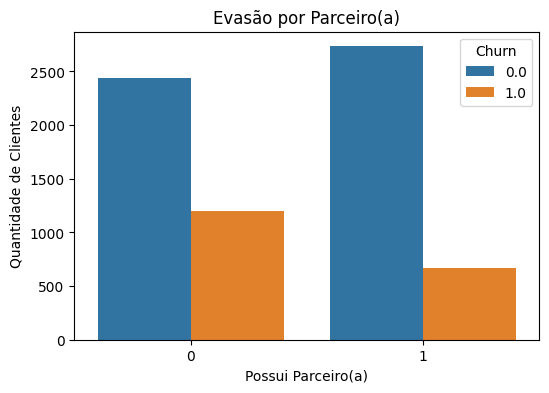

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='customer.Partner', hue='Churn')

plt.title('Evasão por Parceiro(a)')
plt.xlabel('Possui Parceiro(a)')
plt.ylabel('Quantidade de Clientes')

plt.show()

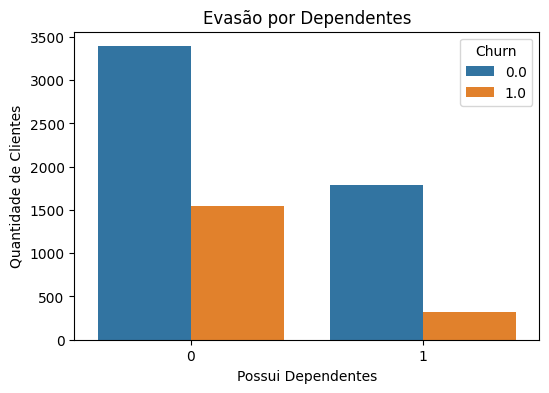

In [69]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='customer.Dependents', hue='Churn')

plt.title('Evasão por Dependentes')
plt.xlabel('Possui Dependentes')
plt.ylabel('Quantidade de Clientes')

plt.show()

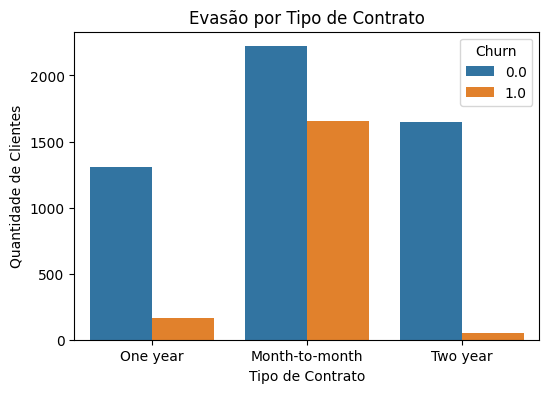

In [70]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='account.Contract', hue='Churn')

plt.title('Evasão por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')

plt.show()

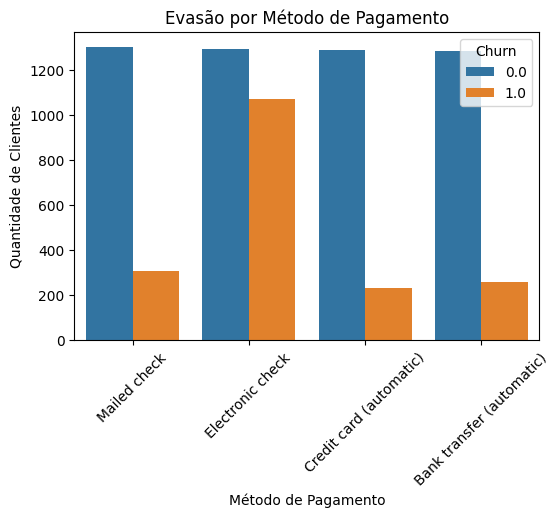

In [71]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='account.PaymentMethod', hue='Churn')

plt.title('Evasão por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Clientes')

plt.xticks(rotation=45)

plt.show()

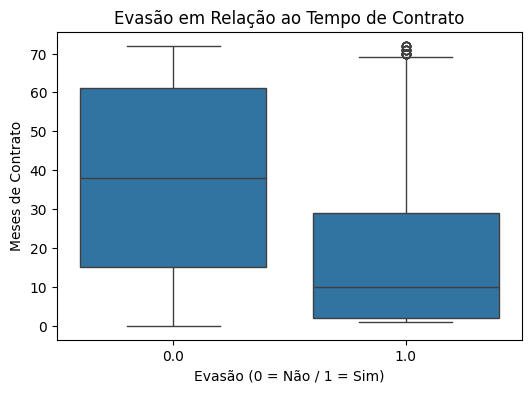

In [73]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='Churn', y='customer.tenure')

plt.title('Evasão em Relação ao Tempo de Contrato')
plt.xlabel('Evasão (0 = Não / 1 = Sim)')
plt.ylabel('Meses de Contrato')

plt.show()

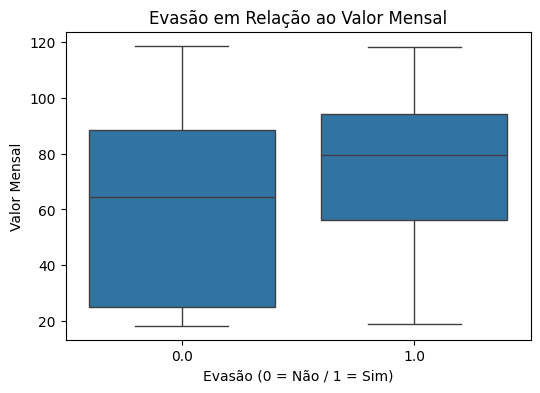

In [78]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Evasão em Relação ao Valor Mensal')
plt.xlabel('Evasão (0 = Não / 1 = Sim)')
plt.ylabel('Valor Mensal')

plt.show()

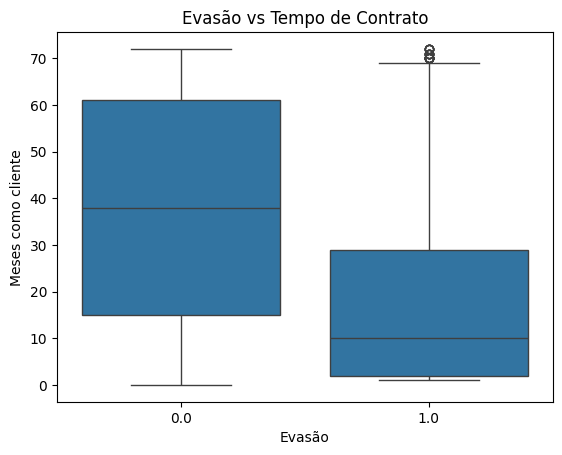

In [80]:
plt.figure()

sns.boxplot(data=df, x='Churn', y='customer.tenure')

plt.title('Evasão vs Tempo de Contrato')
plt.xlabel('Evasão')
plt.ylabel('Meses como cliente')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.countplot(data=df, x='Churn')

plt.title('Distribuição de Cancelamento de Clientes')
plt.xlabel('Churn')
plt.ylabel('Quantidade de Clientes')

plt.show()


In [ ]:
plt.figure()

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Cancelamento por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade')

plt.show()


In [ ]:
plt.figure()

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)

plt.title('Tempo de Contrato vs Cancelamento')
plt.xlabel('Meses como cliente')
plt.ylabel('Quantidade')

plt.show()


In [ ]:
plt.figure()

sns.boxplot(data=df, x='Churn', y='Charges.Monthly')

plt.title('Valor Mensal vs Cancelamento')
plt.xlabel('Churn')
plt.ylabel('Cobrança Mensal')

plt.show()


In [ ]:
plt.figure()

sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Cancelamento por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Quantidade')

plt.show()


In [28]:
plt.figure()

correlacao = df[['account.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].corr()

sns.heatmap(correlacao, annot=True)

plt.title('Correlação entre Variáveis Numéricas')

plt.show()


KeyError: "['account.tenure'] not in index"

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure()

sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.title('Cancelamento por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# calcular taxa de churn
churn_contract = (
    df.groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .rename('percent')
    .mul(100)
    .reset_index()
)

# filtrar apenas churn = Yes
churn_contract = churn_contract[churn_contract['Churn'] == 'Yes']

plt.figure()

sns.barplot(data=churn_contract, x='Contract', y='percent')

plt.title('Taxa de Churn (%) por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Taxa de Churn (%)')

plt.show()
``


In [ ]:
churn_internet = (
    df.groupby('InternetService')['Churn']
    .value_counts(normalize=True)
    .rename('percent')
    .mul(100)
    .reset_index()
)

churn_internet = churn_internet[churn_internet['Churn'] == 'Yes']

plt.figure()

sns.barplot(data=churn_internet, x='InternetService', y='percent')

plt.title('Taxa de Churn (%) por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Taxa de Churn (%)')

plt.show()


In [ ]:
servicos = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

dados_heatmap = []

for servico in servicos:

    taxa = (
        df.groupby(servico)['Churn']
        .value_counts(normalize=True)
        .rename('percent')
        .mul(100)
        .reset_index()
    )

    taxa = taxa[ taxa['Churn'] == 'Yes' ]

    taxa['Service'] = servico
    taxa['Status'] = taxa[servico]

    dados_heatmap.append(taxa)

heatmap_df = pd.concat(dados_heatmap)

pivot = heatmap_df.pivot(index='Service', columns='Status', values='percent')

plt.figure()

sns.heatmap(pivot, annot=True)

plt.title('Taxa de Churn por Serviços Adicionais')

plt.show()

In [ ]:
1 - Importação das bibliotecas
2 - Coleta de dados (API)
3 - Tratamento de dados (ETL)
4 - Exploração inicial
5 - Análise exploratória (EDA)
      • distribuição churn
      • churn por contrato
      • churn por internet
      • churn por serviços
      • churn por tempo
6 - Insights estratégicos


# 7. Insights

# 📊 Relatório Final — Análise de Evasão de Clientes (Churn)

## 1. Introdução

O objetivo deste projeto é analisar os fatores que influenciam a evasão de clientes (Churn) na empresa Telecom X. A evasão de clientes representa um grande desafio para empresas de serviços recorrentes, pois clientes que cancelam seus contratos geram perda de receita e aumento dos custos de aquisição de novos consumidores.

A partir de um conjunto de dados contendo informações demográficas, serviços contratados e dados financeiros dos clientes, esta análise busca identificar padrões e variáveis que estão associadas ao cancelamento do serviço.

Com base nessas informações, é possível gerar insights que auxiliem a empresa na criação de estratégias de retenção e redução da evasão.

## 2. Limpeza e Tratamento de Dados

Inicialmente, os dados foram coletados diretamente de uma API no formato JSON e convertidos para um DataFrame utilizando a biblioteca Pandas, permitindo a manipulação e análise das informações.

Durante a etapa de preparação dos dados, foram realizadas diversas verificações para garantir a qualidade das informações:

Verificação da estrutura do dataset e tipos de dados

Identificação de valores ausentes

Verificação de registros duplicados

Análise de inconsistências nas variáveis categóricas

Conversão de variáveis para tipos apropriados

Padronização de variáveis

Algumas transformações importantes incluíram:

Conversão da variável TotalCharges para formato numérico

Tratamento de valores nulos substituindo por valores apropriados

Transformação da variável Churn em formato binário (1 para evasão e 0 para permanência)

Padronização de variáveis categóricas como Partner e Dependents

Renomeação de colunas para facilitar a análise

Essas etapas garantiram que os dados estivessem limpos, consistentes e preparados para a análise exploratória.

## 3. Análise Exploratória de Dados (EDA)

Na etapa de análise exploratória, foram realizadas diversas visualizações e análises estatísticas com o objetivo de compreender melhor o comportamento dos clientes e identificar fatores associados à evasão.

Inicialmente, foi analisada a distribuição da variável Churn, permitindo entender a proporção de clientes que cancelaram o serviço em comparação com os que permaneceram.

Em seguida, foram analisadas variáveis categóricas relevantes, como:

gênero do cliente

tipo de contrato

método de pagamento

tipo de serviço de internet

serviços adicionais contratados

Os gráficos indicaram diferenças importantes nas taxas de evasão entre diferentes perfis de clientes.

Também foram analisadas variáveis numéricas, como:

tempo de contrato (tenure)

valor mensal pago (MonthlyCharges)

valor total pago (TotalCharges)

Essas análises permitiram identificar padrões de comportamento que ajudam a explicar por que alguns clientes apresentam maior probabilidade de cancelar o serviço.

## 4. Conclusões e Insights

A análise dos dados revelou alguns padrões importantes relacionados à evasão de clientes.

### 📊 Insight 1 — Contratos curtos geram mais churn

Clientes com contratos mensais apresentam uma taxa de cancelamento significativamente maior em comparação com clientes que possuem contratos anuais ou de dois anos.

➡ Isso indica que contratos mais longos ajudam a reduzir a evasão.

### 📊 Insight 2 — Clientes novos cancelam mais

Clientes com menor tempo de contrato (tenure) possuem maior probabilidade de cancelar o serviço.

➡ Isso sugere que os primeiros meses de relacionamento com o cliente são críticos para retenção.

### 📊 Insight 3 — Falta de serviços adicionais aumenta churn

Clientes que não possuem serviços adicionais como OnlineSecurity e TechSupport apresentam maiores taxas de cancelamento.

➡ A ausência desses serviços pode indicar menor engajamento com a plataforma.

### 📊 Insight 4 — Cobranças mensais maiores aumentam churn

Clientes com valores mensais mais elevados (MonthlyCharges) tendem a apresentar maior evasão.

➡ Isso pode indicar percepção de custo elevado ou baixa percepção de valor do serviço.

## 5. Recomendações

Com base nos padrões identificados na análise, algumas estratégias podem ser adotadas pela empresa para reduzir a evasão de clientes.

🎯 Incentivar contratos de longo prazo

Oferecer descontos ou benefícios para clientes que optarem por contratos anuais ou bianuais pode reduzir significativamente a taxa de cancelamento.

🎯 Criar programas de retenção para novos clientes

Como clientes com pouco tempo de contrato possuem maior churn, a empresa pode implementar:

onboarding mais estruturado

acompanhamento nos primeiros meses

ofertas de fidelização

🎯 Promover serviços adicionais

Pacotes que incluam serviços como segurança online, suporte técnico e backup podem aumentar o valor percebido do serviço e reduzir a evasão.

🎯 Revisar estrutura de preços

Clientes com maiores valores mensais apresentam maior tendência de cancelamento. Estratégias como:

planos com melhor custo-benefício

pacotes combinados

descontos progressivos

podem ajudar a melhorar a retenção.

## ✅ Resultado Final

A análise exploratória permitiu identificar fatores relevantes associados à evasão de clientes na Telecom X. Com base nesses insights, a empresa pode desenvolver estratégias mais direcionadas para melhorar a retenção e aumentar a satisfação dos clientes.